In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [1]:
kep_wo_chain_01,  kep_wo_phys_01 = np.load("../test_result/array/kep_wo_chain_01.npy"), np.load("../test_result/array/kep_wo_phys_01.npy")
kep_wo_chain_02,  kep_wo_phys_02 = np.load("../test_result/array/kep_wo_chain_02.npy"), np.load("../test_result/array/kep_wo_phys_02.npy")
static_wo_chain_01 = np.load("../test_result/array/static_wo_chain_01.npy")
static_wo_brob_01 = np.load("../test_result/array/static_wo_brob_01.npy")

kep_wo_chain_02[:,10] *= -10

NameError: name 'read_chain' is not defined

In [4]:
kep_wo_phys_01[:,4]

array([0.8772196 , 0.5936744 , 0.6110757 , ..., 0.12209414, 0.34012556,
       0.41747594], shape=(1507,), dtype=float32)

In [5]:
def calc_thE(chain):
    ML = chain[:,3]
    DL = chain[:,4]
    DS = chain[:,5]
    KAPPA = 8.1429 # [mas / Msun]
    
    pirel = 1/DL - 1/DS
    thE = np.sqrt(KAPPA*ML*pirel)
    return thE

In [6]:
kep_wo_thE_01 = calc_thE(kep_wo_phys_01)
kep_wo_thE_02 = calc_thE(kep_wo_phys_02)
static_wo_thE_01 = static_wo_brob_01/static_wo_chain_01[:,3]

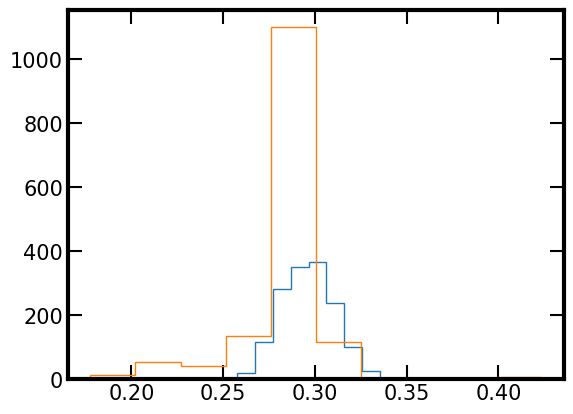

In [7]:
plt.hist(kep_wo_thE_01,histtype="step")
plt.hist(static_wo_thE_01,histtype="step")

plt.show()

In [8]:
def calc_med_err(chain):
    p16, p50, p84 = np.percentile(chain, [16, 50, 84])
    return p50, p84 - p16

In [9]:
tE_med_01, tE_err_01 = calc_med_err(kep_wo_chain_01[:,1])
thE_med_01, thE_err_01 = calc_med_err(kep_wo_thE_01)
piEN_med_01, piEN_err_01 = calc_med_err(kep_wo_chain_01[:,7])
piEE_med_01, piEE_err_01 = calc_med_err(kep_wo_chain_01[:,8])

tE_med_01_st, tE_err_01_st = calc_med_err(static_wo_chain_01[:,1])
thE_med_01_st, thE_err_01_st = calc_med_err(static_wo_thE_01)

tE_med_02, tE_err_02 = calc_med_err(kep_wo_chain_02[:,1])
thE_med_02, thE_err_02 = calc_med_err(kep_wo_thE_02)
piEN_med_02, piEN_err_02 = calc_med_err(kep_wo_chain_02[:,7])
piEE_med_02, piEE_err_02 = calc_med_err(kep_wo_chain_02[:,8])

In [10]:
argtxt = "./genulens "
argtxt += "l 1.5972674  b -2.1130907 "
argtxt += "vEarthlb 0.48  -0.67 "
argtxt += f"tE {round(tE_med_01,3)} {round(tE_err_01,3)} "
argtxt += f"thetaE {round(thE_med_01,3)} {round(thE_err_01,3)} "
argtxt_para = argtxt + f"piEN {round(piEN_med_01,3)} {round(piEN_err_01,3)} "
argtxt_para += f"piEE {round(piEE_med_01,3)} {round(piEE_err_01,3)} "

argtxt_para += "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_para_01.dat"

argtxt_wo_para = argtxt+ "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_wo_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_01.dat"

print(argtxt_wo_para+" &")
print(argtxt_para+" &")

argtxt = "./genulens "
argtxt += "l 1.5972674  b -2.1130907 "
argtxt += "vEarthlb 0.48  -0.67 "
argtxt += f"tE {round(tE_med_01_st,3)} {round(tE_err_01_st,3)} "
argtxt += f"thetaE {round(thE_med_01_st,3)} {round(thE_err_01_st,3)} "

argtxt_wo_para = argtxt+ "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_wo_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_static_01.dat"

print("\n")
print(argtxt_wo_para+" &")
print("\n")

argtxt = "./genulens "
argtxt += "l 1.5972674  b -2.1130907 "
argtxt += "vEarthlb 0.48  -0.67 "
argtxt += f"tE {round(tE_med_02,3)} {round(tE_err_02,3)} "
argtxt += f"thetaE {round(thE_med_02,3)} {round(thE_err_02,3)} "
argtxt_para = argtxt + f"piEN {round(piEN_med_02,3)} {round(piEN_err_02,3)} "
argtxt_para += f"piEE {round(piEE_med_02,3)} {round(piEE_err_02,3)} "

argtxt_para += "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_para_02.dat"

argtxt_wo_para = argtxt+ "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_wo_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_02.dat"

print(argtxt_wo_para+" &")
print(argtxt_para+" &")

./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 57.412 2.318 thetaE 0.296 0.028 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_01.dat &
./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 57.412 2.318 thetaE 0.296 0.028 piEN -0.233 0.286 piEE 0.152 0.147 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_para_01.dat &


./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 58.322 1.323 thetaE 0.287 0.021 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_static_01.dat &


./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 65.982 4.566 thetaE 0.677 0.09 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_02.dat &
./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 65.982 4.566 thetaE 0.677 0.09 piEN -0.165 0.507 piEE 

In [11]:
names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()


def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T


In [12]:
wtj_para_01, genuout_para_01 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_para_01.dat")
wtj_wo_para_01, genuout_wo_para_01 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_01.dat")

wtj_para_02, genuout_para_02 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_para_02.dat")
wtj_wo_para_02, genuout_wo_para_02 = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_wo_para_02.dat")

In [13]:
ranges = [
    (-0.3, 1.8),      
    (1, 11),      
    (3, 18),     
    (-15, 15),         
    (-15, 15),         
]


def cut_genuout(genuout,wtj):
    genuout = genuout[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    genuout = genuout[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    genuout = genuout[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    genuout = genuout[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    genuout = genuout[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    wtj = wtj[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    wtj = wtj[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    wtj = wtj[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    wtj = wtj[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    wtjt = wtj[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    return genuout, wtj
    
genuout_para_01,wtj_para_01 = cut_genuout(genuout_para_01,wtj_para_01)
genuout_para_02,wtj_para_02 = cut_genuout(genuout_para_02,wtj_para_02)

genuout_wo_para_01,wtj_wo_para_01 = cut_genuout(genuout_wo_para_01,wtj_wo_para_01)
genuout_wo_para_02,wtj_wo_para_02 = cut_genuout(genuout_wo_para_02,wtj_wo_para_02)

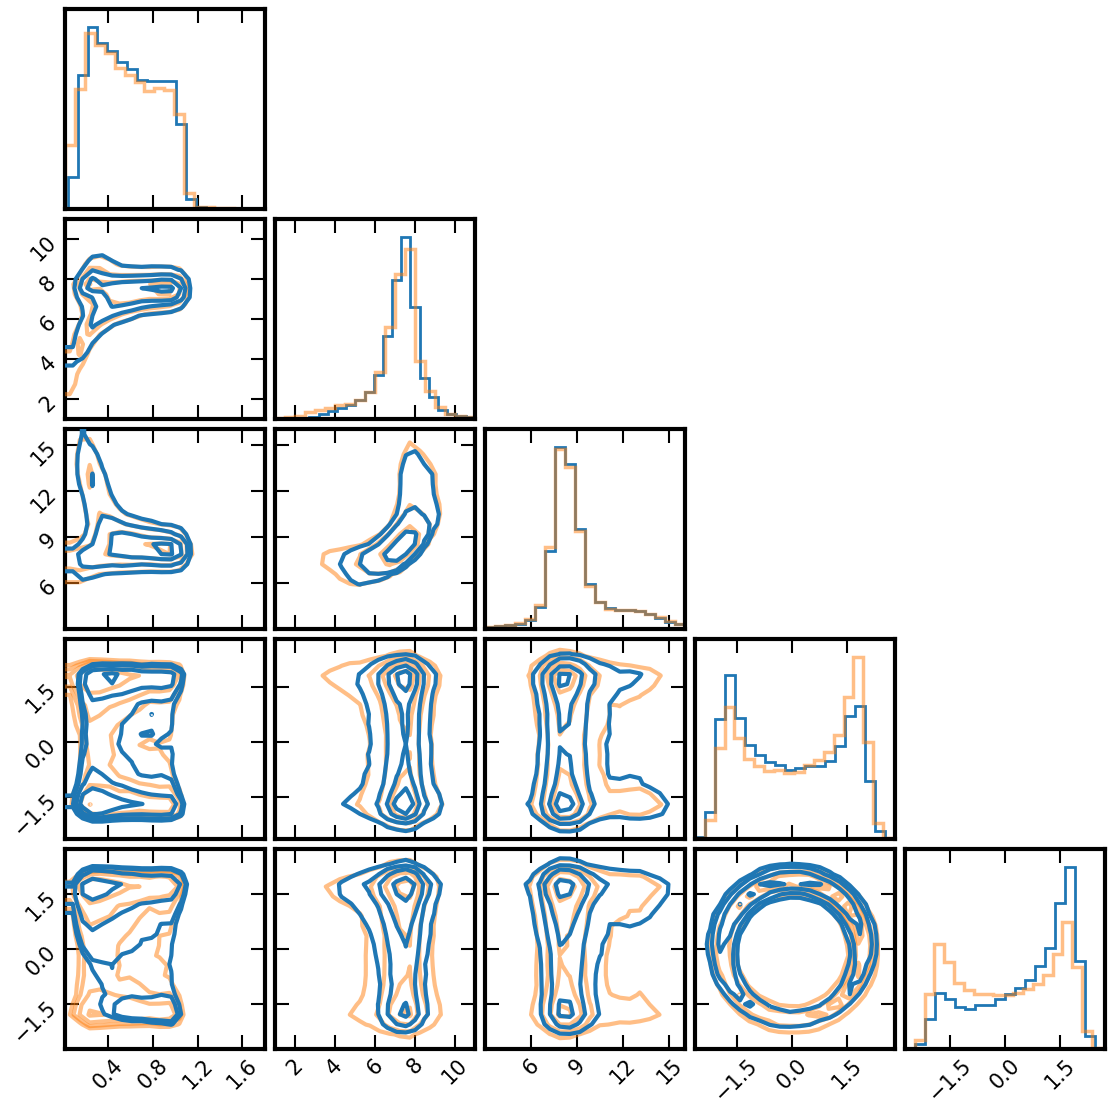

In [14]:
fig = corner.corner(genuout_para_01,
                    weights=wtj_para_01,
            fill_contours=False, plot_density=False,
              color="C0",     hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
            contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":1,"zorder":10},
            show_titles=False,
            plot_datapoints=False, smooth=1.0/2)

corner.corner(
    genuout_wo_para_01,
    weights=wtj_wo_para_01,
    fig=fig,
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2
)

plt.show()

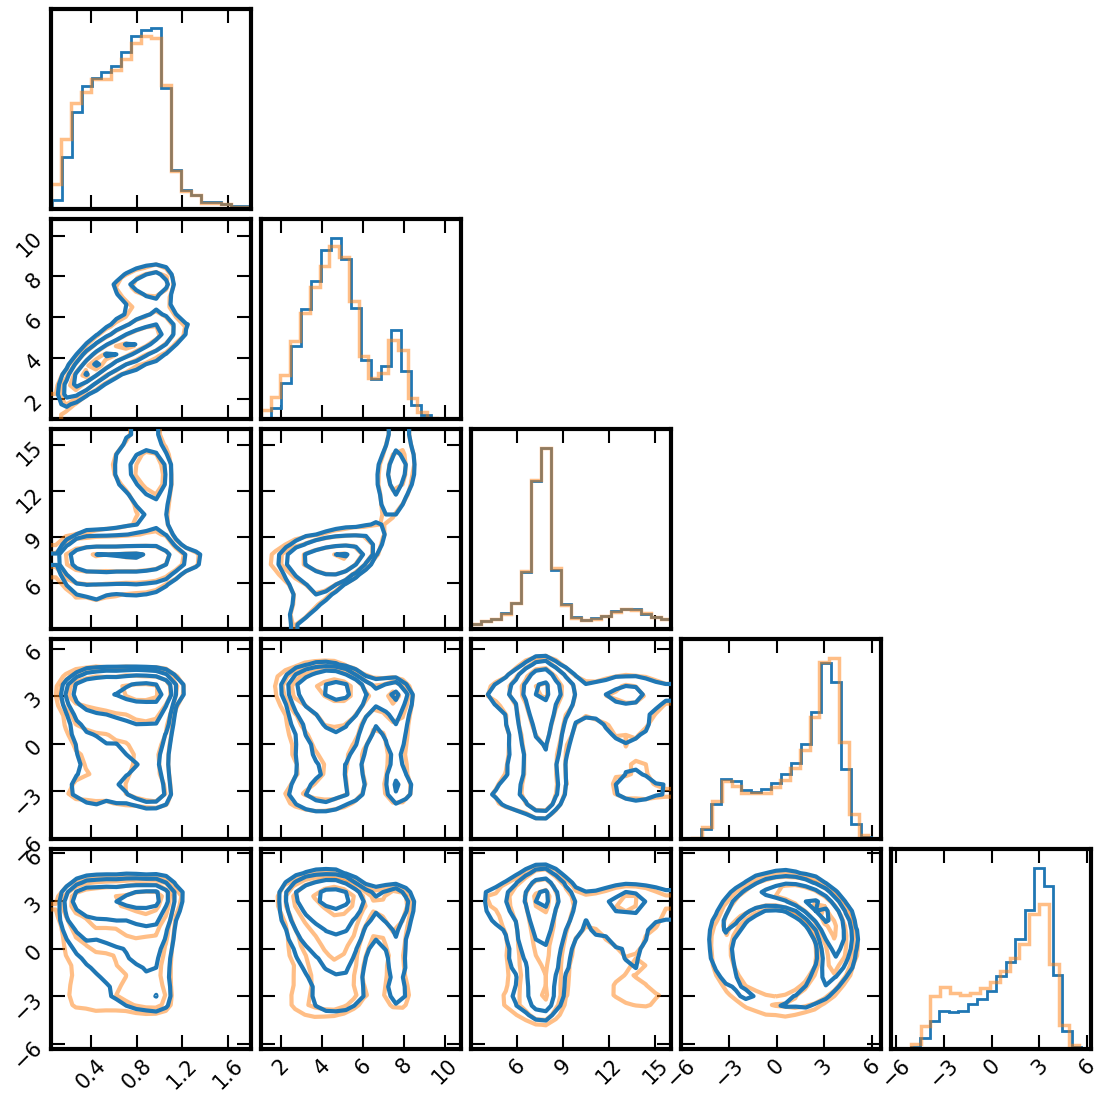

In [15]:
fig = corner.corner(genuout_para_02,
                    weights=wtj_para_02,
            fill_contours=False, plot_density=False,
              color="C0",     hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
            contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":1,"zorder":10},
            show_titles=False,
            plot_datapoints=False, smooth=1.0/2)

corner.corner(
    genuout_wo_para_02,
    weights=wtj_wo_para_02,
    fig=fig,
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2
)

plt.show()